In [ ]:
# Access the files from google drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import numpy as np

# for visualizing data
import matplotlib.pyplot as plt
import seaborn as sns

# For randomized data splitting
from sklearn.model_selection import train_test_split

# To build linear regression_model
import statsmodels.api as sm

# To check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Read the dataset
df = pd.read_csv('/content/drive/My Drive/ottdata.csv',encoding='unicode_escape')
print(df)

Mounted at /content/drive
     visitors  ad_impressions  major_sports_event     genre  dayofweek  \
0        1.67         1113.81                   0    Horror  Wednesday   
1        1.46         1498.41                   1  Thriller     Friday   
2        1.47         1079.19                   1  Thriller  Wednesday   
3        1.85         1342.77                   1    Sci-Fi     Friday   
4        1.46         1498.41                   0    Sci-Fi     Sunday   
..        ...             ...                 ...       ...        ...   
995      1.58         1311.96                   0   Romance     Friday   
996      1.34         1329.48                   0    Action     Friday   
997      1.62         1359.80                   1    Sci-Fi  Wednesday   
998      2.06         1698.35                   0   Romance     Monday   
999      1.36         1140.23                   0    Comedy   Saturday   

     season  views_trailer  views_content  
0    Spring          56.70           0.51

In [ ]:
df.head()

,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
0,1.67,1113.81,0,Horror,Wednesday,Spring,56.70,0.51
1,1.46,1498.41,1,Thriller,Friday,Fall,52.69,0.32
2,1.47,1079.19,1,Thriller,Wednesday,Fall,48.74,0.39
3,1.85,1342.77,1,Sci-Fi,Friday,Fall,49.81,0.44
4,1.46,1498.41,0,Sci-Fi,Sunday,Winter,55.83,0.46


In [ ]:
df.shape

(1000, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visitors            1000 non-null   float64
 1   ad_impressions      1000 non-null   float64
 2   major_sports_event  1000 non-null   int64  
 3   genre               1000 non-null   object 
 4   dayofweek           1000 non-null   object 
 5   season              1000 non-null   object 
 6   views_trailer       1000 non-null   float64
 7   views_content       1000 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 62.6+ KB


In [ ]:
df.isnull().sum()

,0
visitors,0
ad_impressions,0
major_sports_event,0
genre,0
dayofweek,0
season,0
views_trailer,0
views_content,0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
visitors,1000.0,1.70429,0.231973,1.25,1.5500,1.70,1.830,2.34
ad_impressions,1000.0,1434.71229,289.534834,1010.87,1210.3300,1383.58,1623.670,2424.20
major_sports_event,1000.0,0.40000,0.490143,0.00,0.0000,0.00,1.000,1.00
views_trailer,1000.0,66.91559,35.001080,30.08,50.9475,53.96,57.755,199.92
views_content,1000.0,0.47340,0.105914,0.22,0.4000,0.45,0.520,0.89


In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
visitors,1000.0,NaN,NaN,NaN,1.70429,0.231973,1.25,1.55,1.7,1.83,2.34
ad_impressions,1000.0,NaN,NaN,NaN,1434.71229,289.534834,1010.87,1210.33,1383.58,1623.67,2424.2
major_sports_event,1000.0,NaN,NaN,NaN,0.4,0.490143,0.0,0.0,0.0,1.0,1.0
genre,1000,8,Others,255,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dayofweek,1000,7,Friday,369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,1000,4,Winter,257,NaN,NaN,NaN,NaN,NaN,NaN,NaN
views_trailer,1000.0,NaN,NaN,NaN,66.91559,35.00108,30.08,50.9475,53.96,57.755,199.92
views_content,1000.0,NaN,NaN,NaN,0.4734,0.105914,0.22,0.4,0.45,0.52,0.89


In [ ]:
df.duplicated().sum()

np.int64(0)

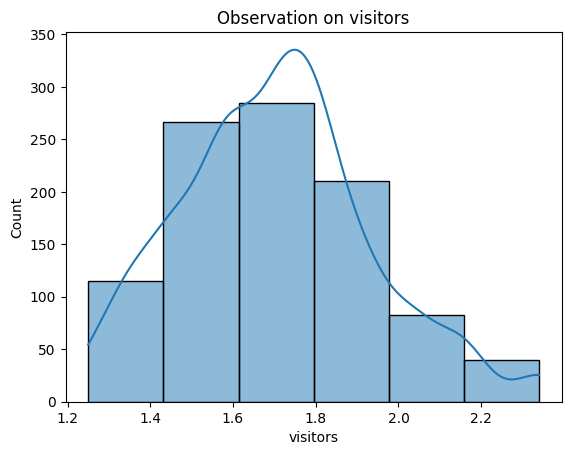

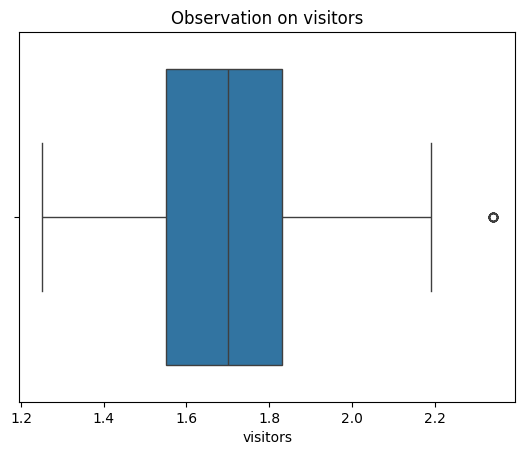

In [ ]:
plt.title('Observation on visitors')
sns.histplot(data=df,x='visitors',kde=True,bins=6);
plt.show()

plt.title('Observation on visitors')
sns.boxplot(data=df,x='visitors');
plt.show()

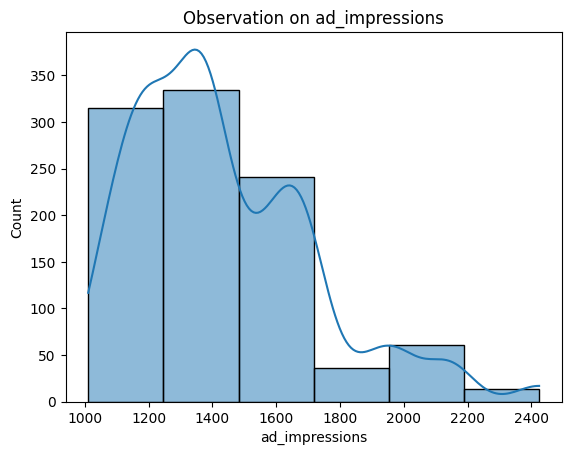

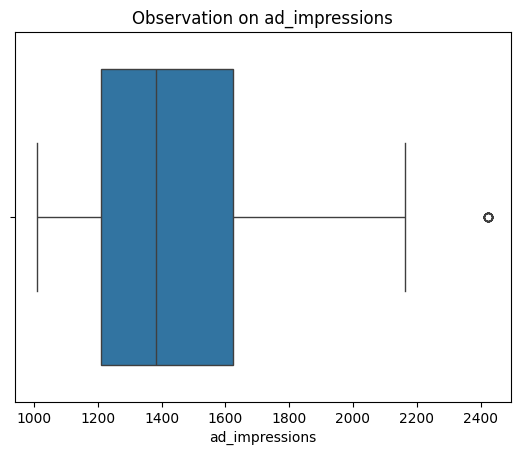

In [ ]:
plt.title('Observation on ad_impressions')
sns.histplot(data=df,x='ad_impressions',kde=True,bins=6);
plt.show()

plt.title('Observation on ad_impressions')
sns.boxplot(data=df,x='ad_impressions');
plt.show()

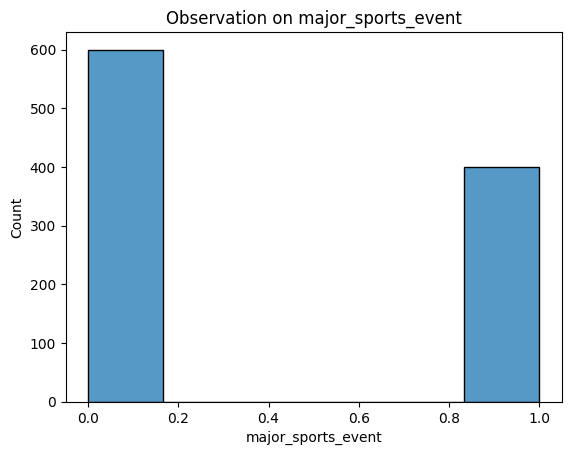

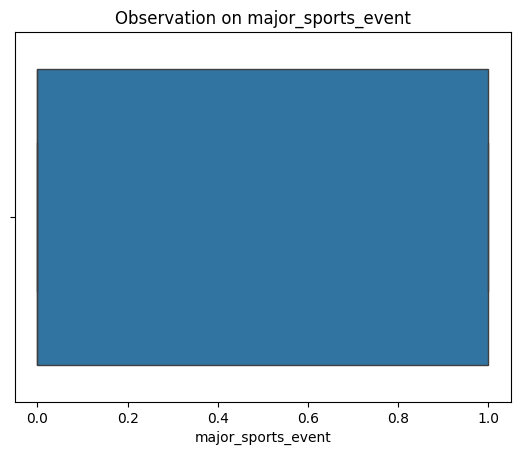

In [ ]:
plt.title('Observation on major_sports_event')
sns.histplot(data=df,x='major_sports_event',bins=6);
plt.show()

plt.title('Observation on major_sports_event')
sns.boxplot(data=df,x='major_sports_event');
plt.show()

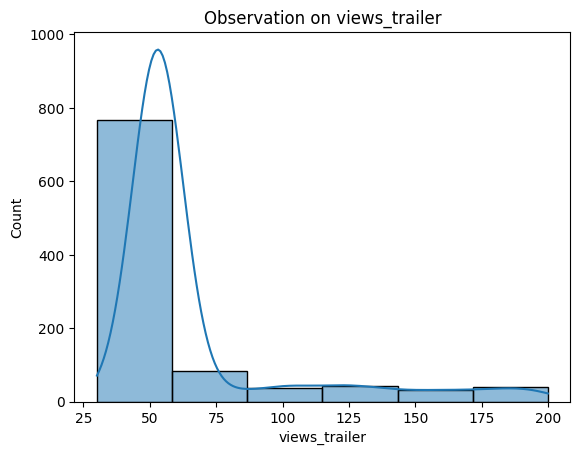

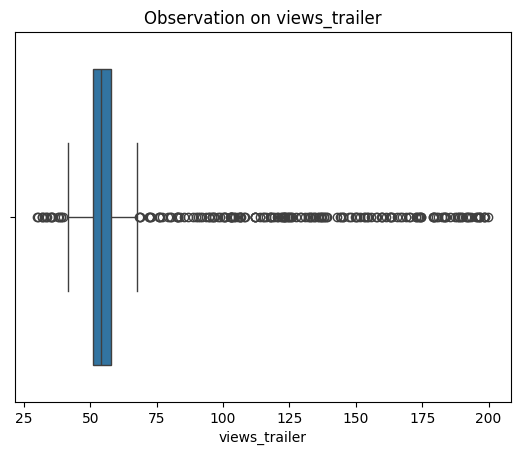

In [ ]:
plt.title('Observation on views_trailer')
sns.histplot(data=df,x='views_trailer',kde=True,bins=6);
plt.show()

plt.title('Observation on views_trailer')
sns.boxplot(data=df,x='views_trailer');
plt.show()

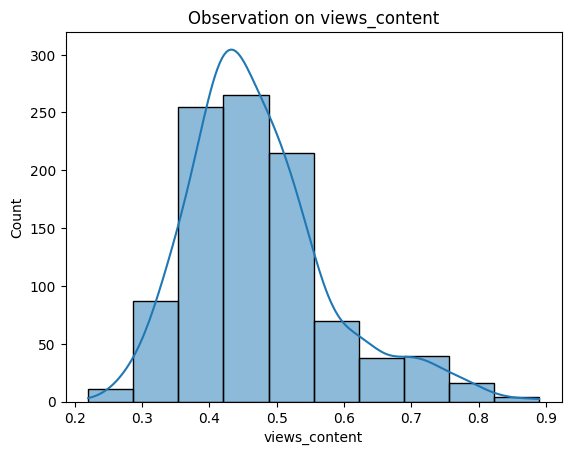

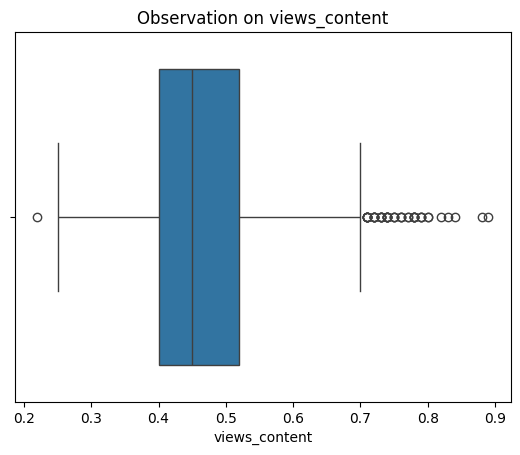

In [ ]:

plt.title('Observation on views_content')
sns.histplot(data=df,x='views_content',bins=10,kde=True);
plt.show()

plt.title('Observation on views_content')
sns.boxplot(data=df,x='views_content');
plt.show()

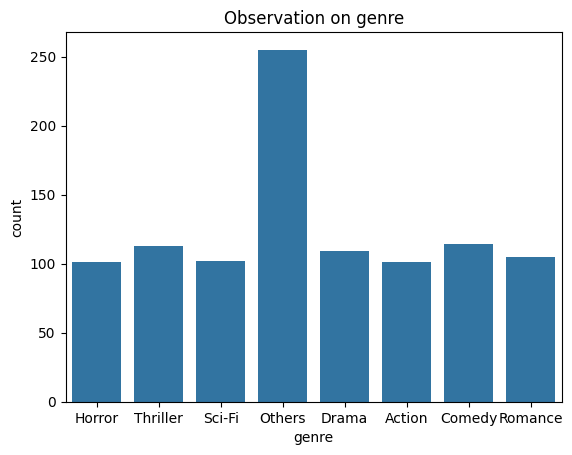

In [ ]:
plt.title('Observation on genre')
sns.countplot(data=df,x='genre');
plt.show()

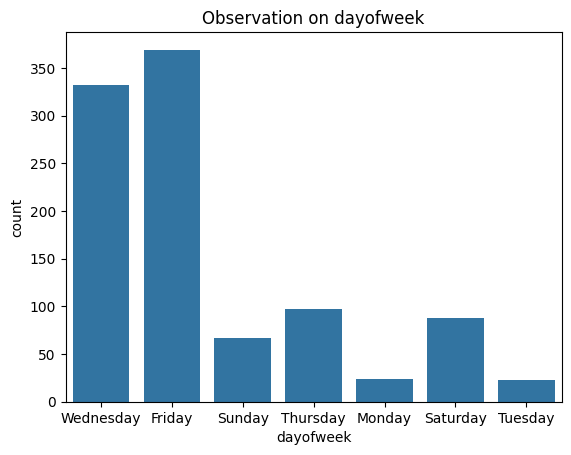

In [ ]:
plt.title('Observation on dayofweek')
sns.countplot(data=df,x='dayofweek');
plt.show()

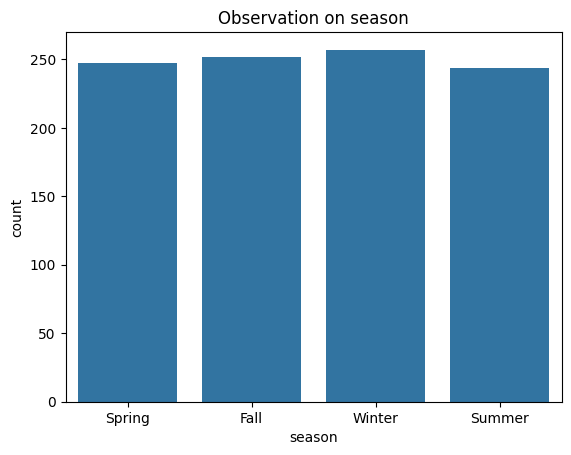

In [ ]:
plt.title('Observation on season')
sns.countplot(data=df,x='season');
plt.show()

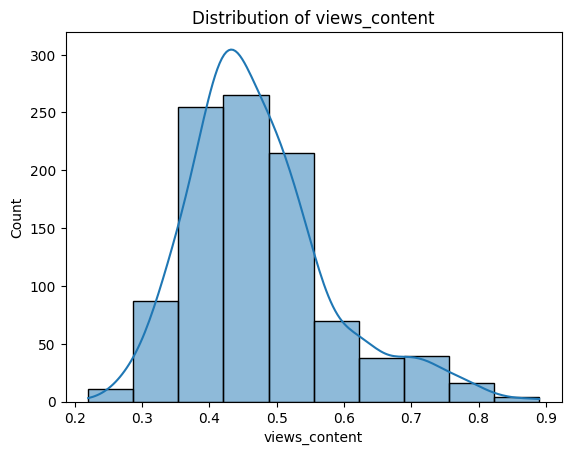

In [ ]:
plt.title('Distribution of views_content')
sns.histplot(data=df, x='views_content',bins=10, kde=True);
plt.show()

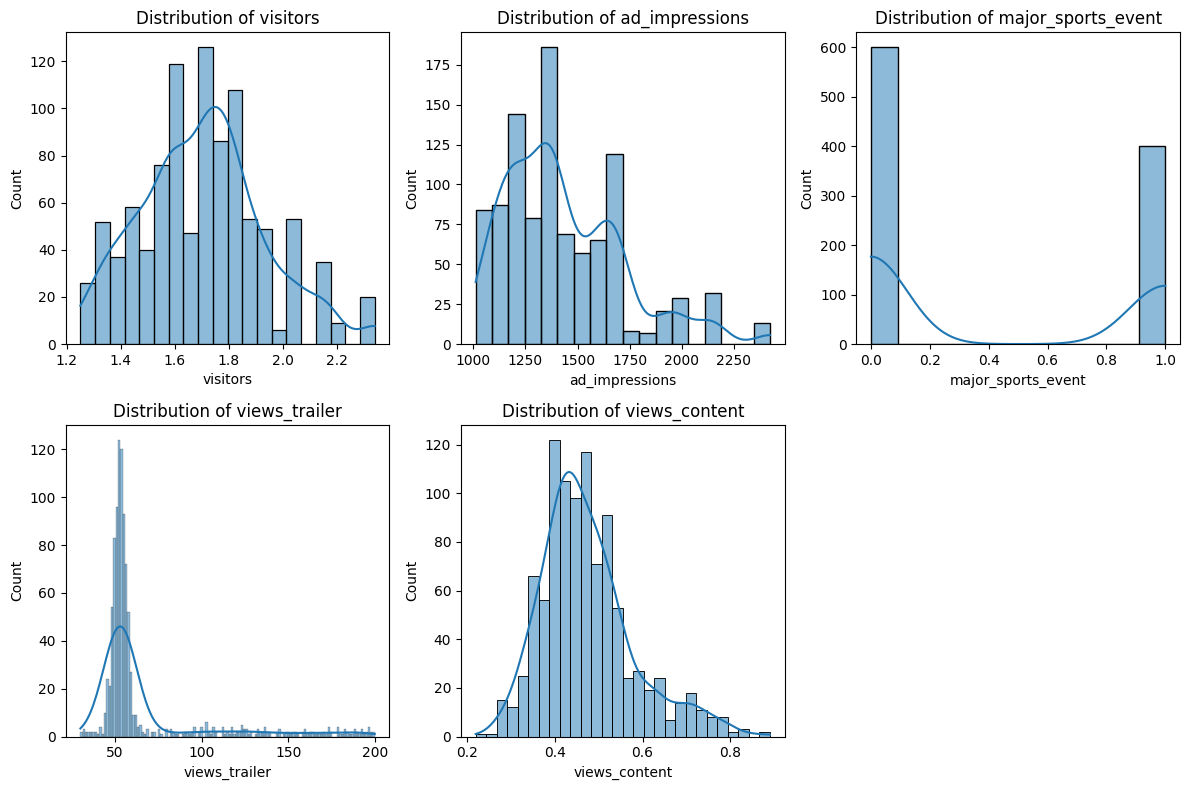

In [ ]:
# plot Distribution of numerical features
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

**Bivariate Analysis**

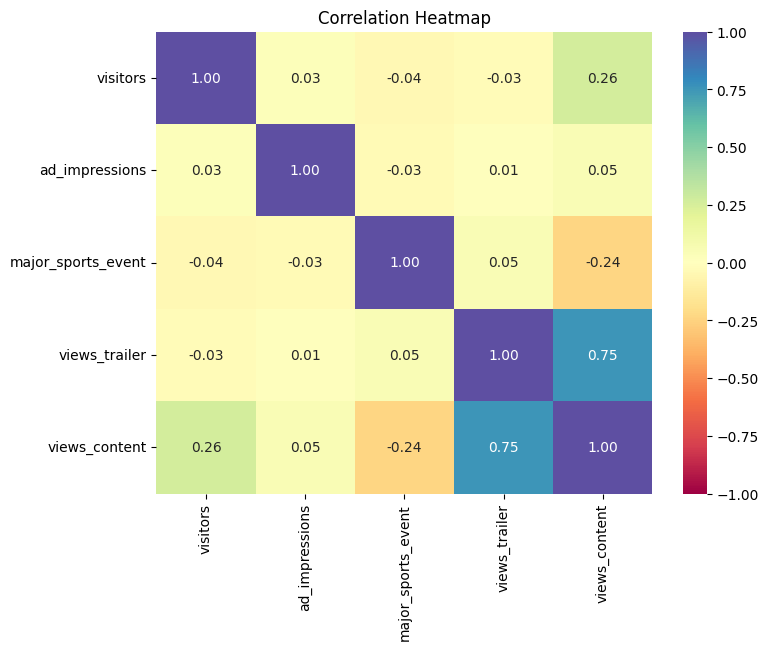

In [ ]:
num_var = ['visitors','ad_impressions','major_sports_event','views_trailer','views_content']
corr= df[num_var].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr,vmin=-1,vmax=1,fmt=".2f",cmap='Spectral',annot=True)
plt.title('Correlation Heatmap')
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Horror'),
  Text(1, 0, 'Thriller'),
  Text(2, 0, 'Sci-Fi'),
  Text(3, 0, 'Others'),
  Text(4, 0, 'Drama'),
  Text(5, 0, 'Action'),
  Text(6, 0, 'Comedy'),
  Text(7, 0, 'Romance')])

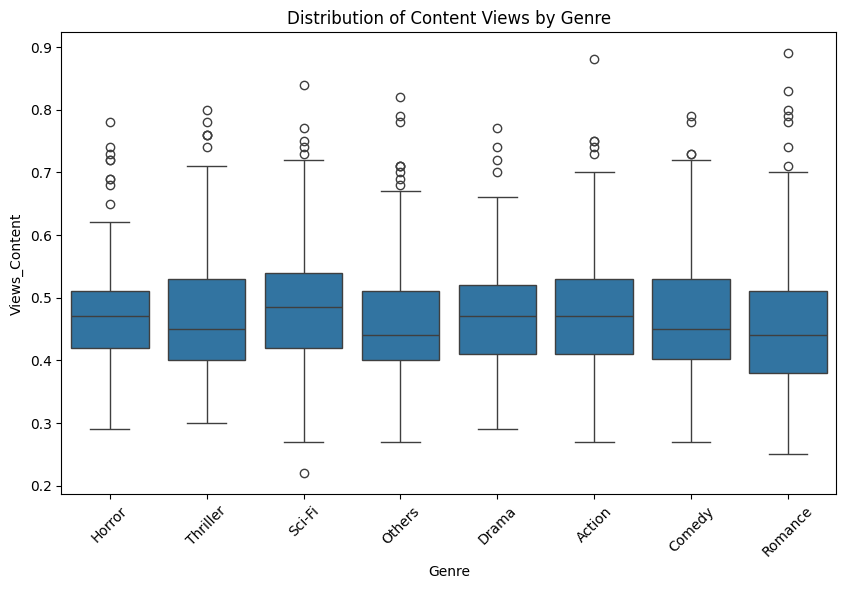

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="genre", y="views_content", )
plt.title("Distribution of Content Views by Genre")
plt.xlabel("Genre")
plt.ylabel("Views_Content")
plt.xticks(rotation=45)

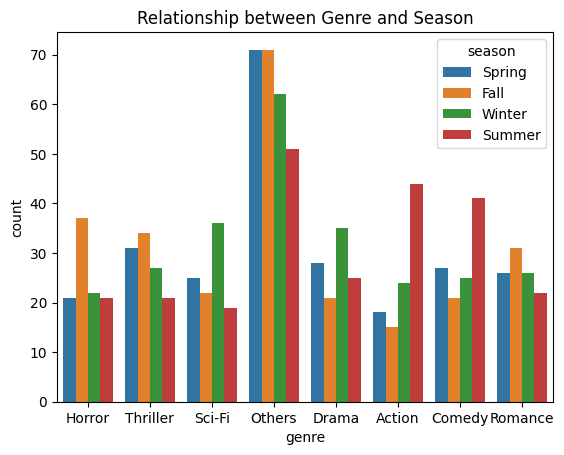

In [ ]:
plt.title('Relationship between Genre and Season')
sns.countplot(data=df,x='genre',hue='season');
plt.show()

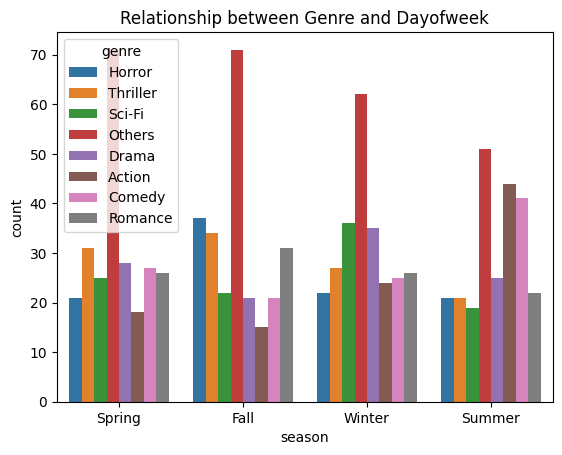

In [ ]:
plt.title('Relationship between Genre and Dayofweek')
sns.countplot(data=df,x='season',hue='genre');
plt.show()

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Wednesday'),
  Text(1, 0, 'Friday'),
  Text(2, 0, 'Sunday'),
  Text(3, 0, 'Thursday'),
  Text(4, 0, 'Monday'),
  Text(5, 0, 'Saturday'),
  Text(6, 0, 'Tuesday')])

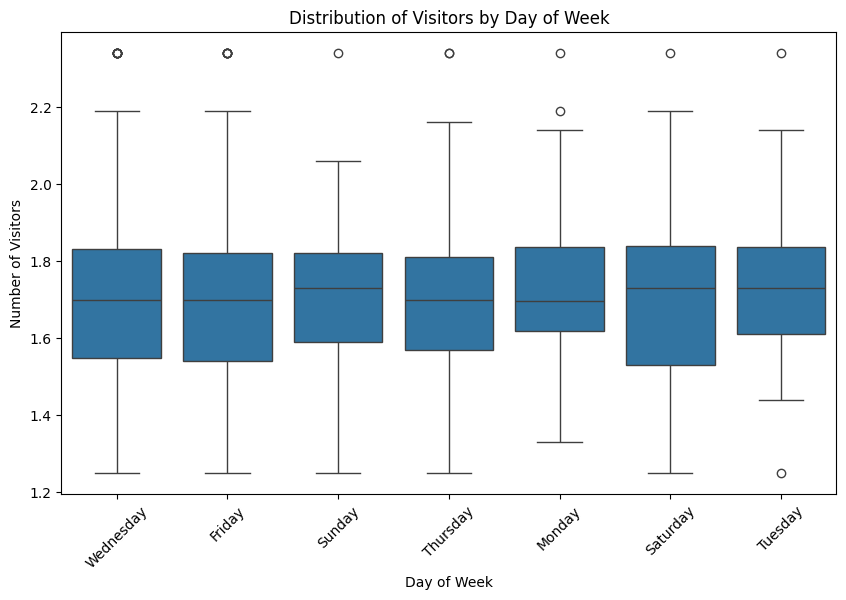

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="dayofweek", y="visitors")
plt.title("Distribution of Visitors by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Visitors")
plt.xticks(rotation=45)

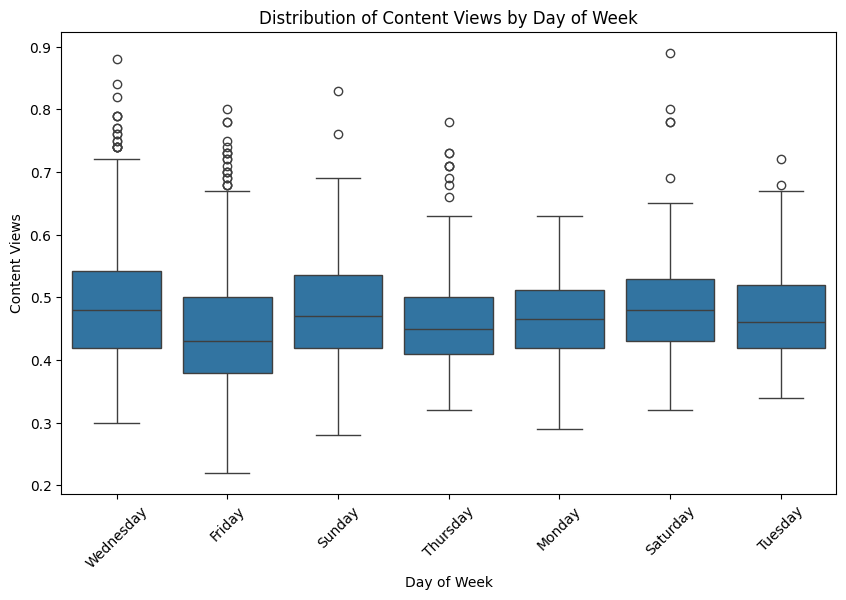

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="dayofweek", y="views_content")
plt.title("Distribution of Content Views by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Content Views")
plt.xticks(rotation=45)
plt.show()

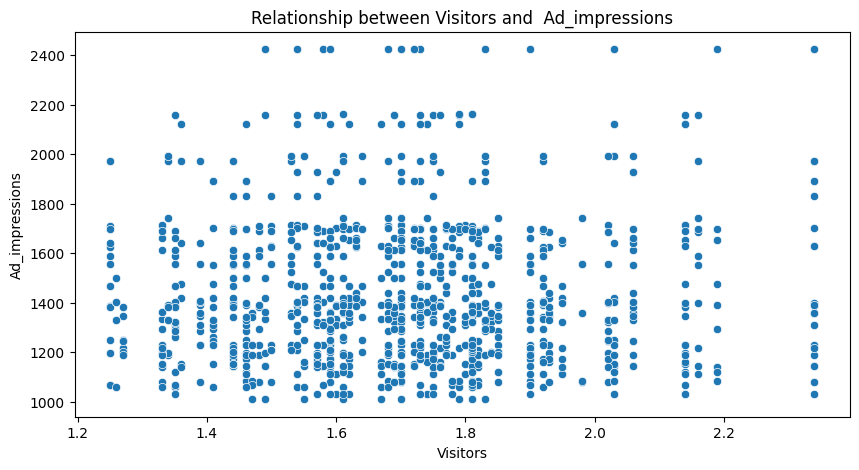

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df,x='visitors',y='ad_impressions');
plt.ylabel('Ad_impressions')
plt.xlabel('Visitors')
plt.title('Relationship between Visitors and  Ad_impressions')
plt.show()

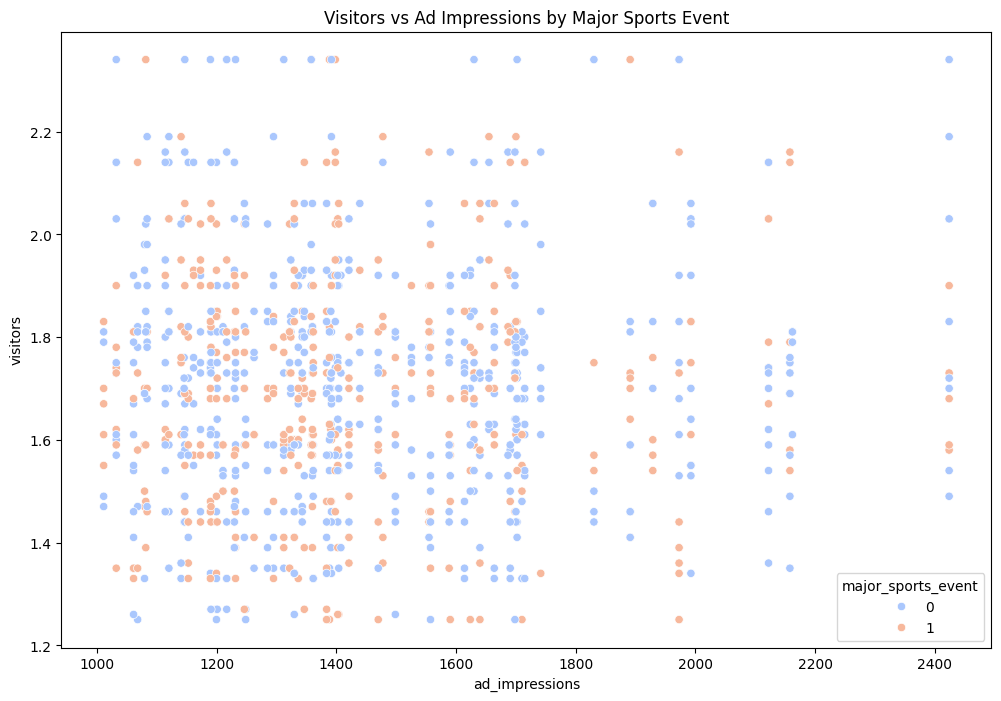

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='ad_impressions', y='visitors', hue='major_sports_event', palette='coolwarm')
plt.title('Visitors vs Ad Impressions by Major Sports Event')
plt.show()

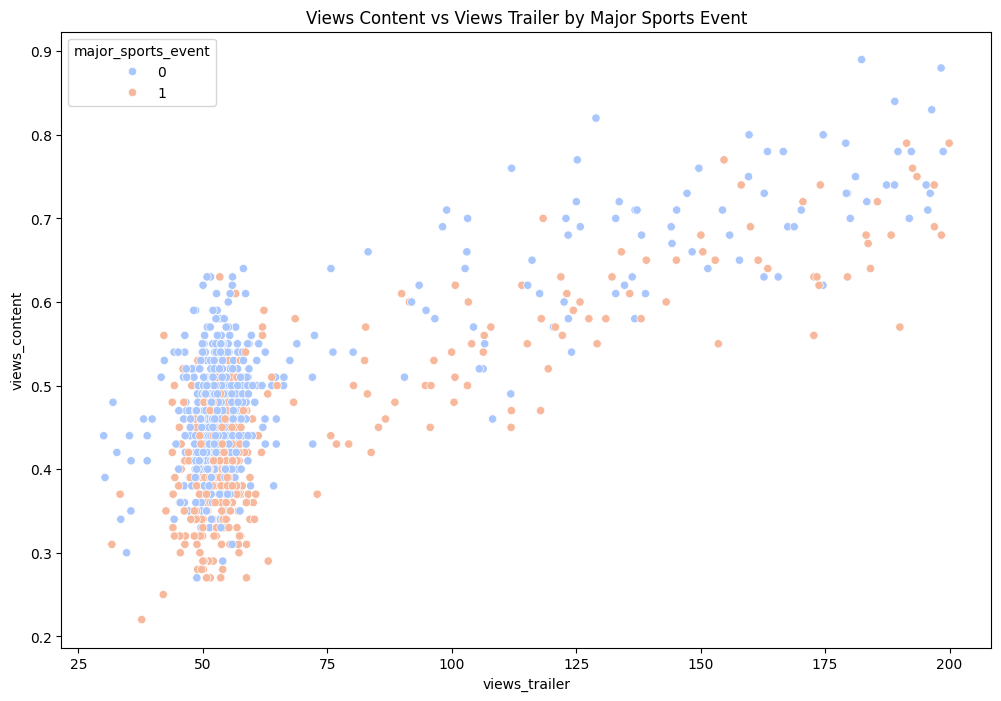

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='views_trailer', y='views_content', hue='major_sports_event', palette='coolwarm')
plt.title('Views Content vs Views Trailer by Major Sports Event')
plt.show()


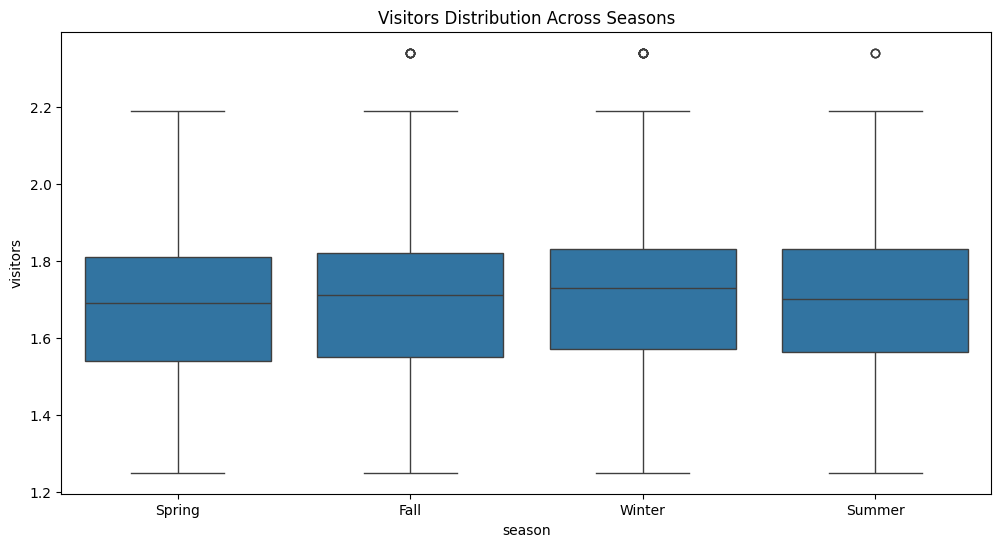

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='season', y='visitors')
plt.title('Visitors Distribution Across Seasons')
plt.show()

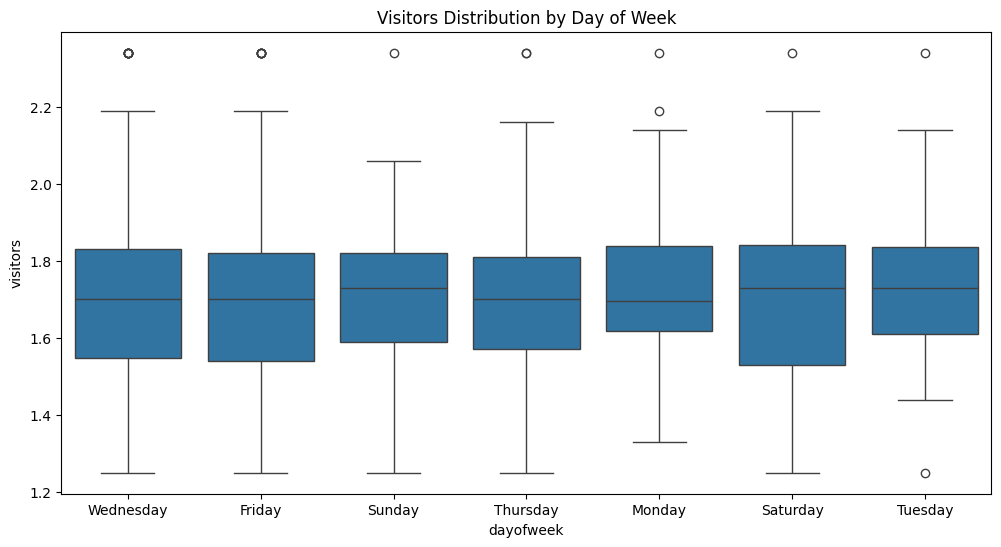

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='dayofweek', y='visitors')
plt.title('Visitors Distribution by Day of Week')
plt.show()

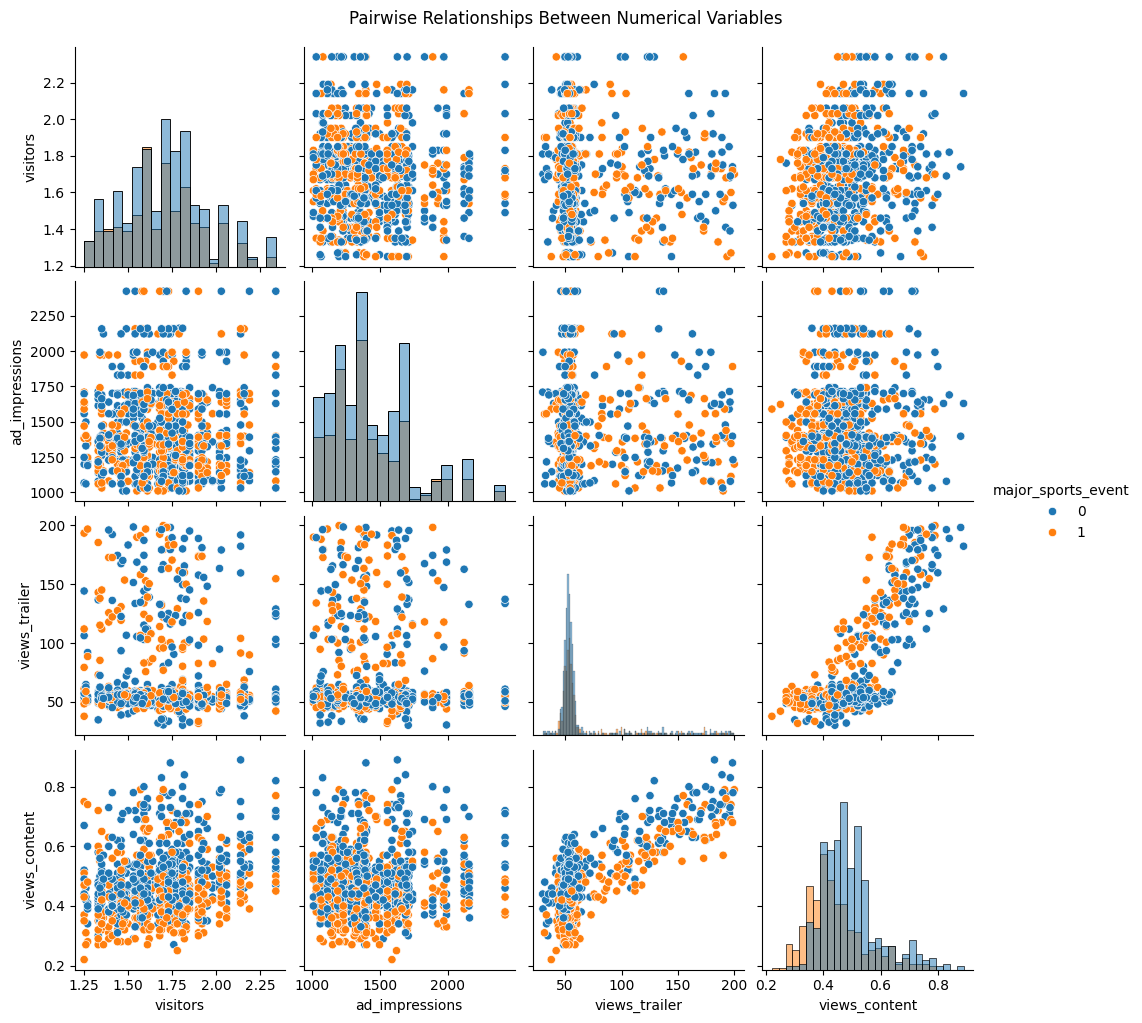

In [ ]:
num_cols = ['visitors', 'ad_impressions', 'views_trailer', 'views_content']
sns.pairplot(df[num_cols + ['major_sports_event']], hue='major_sports_event', diag_kind='hist')
plt.suptitle('Pairwise Relationships Between Numerical Variables', y=1.02)
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/

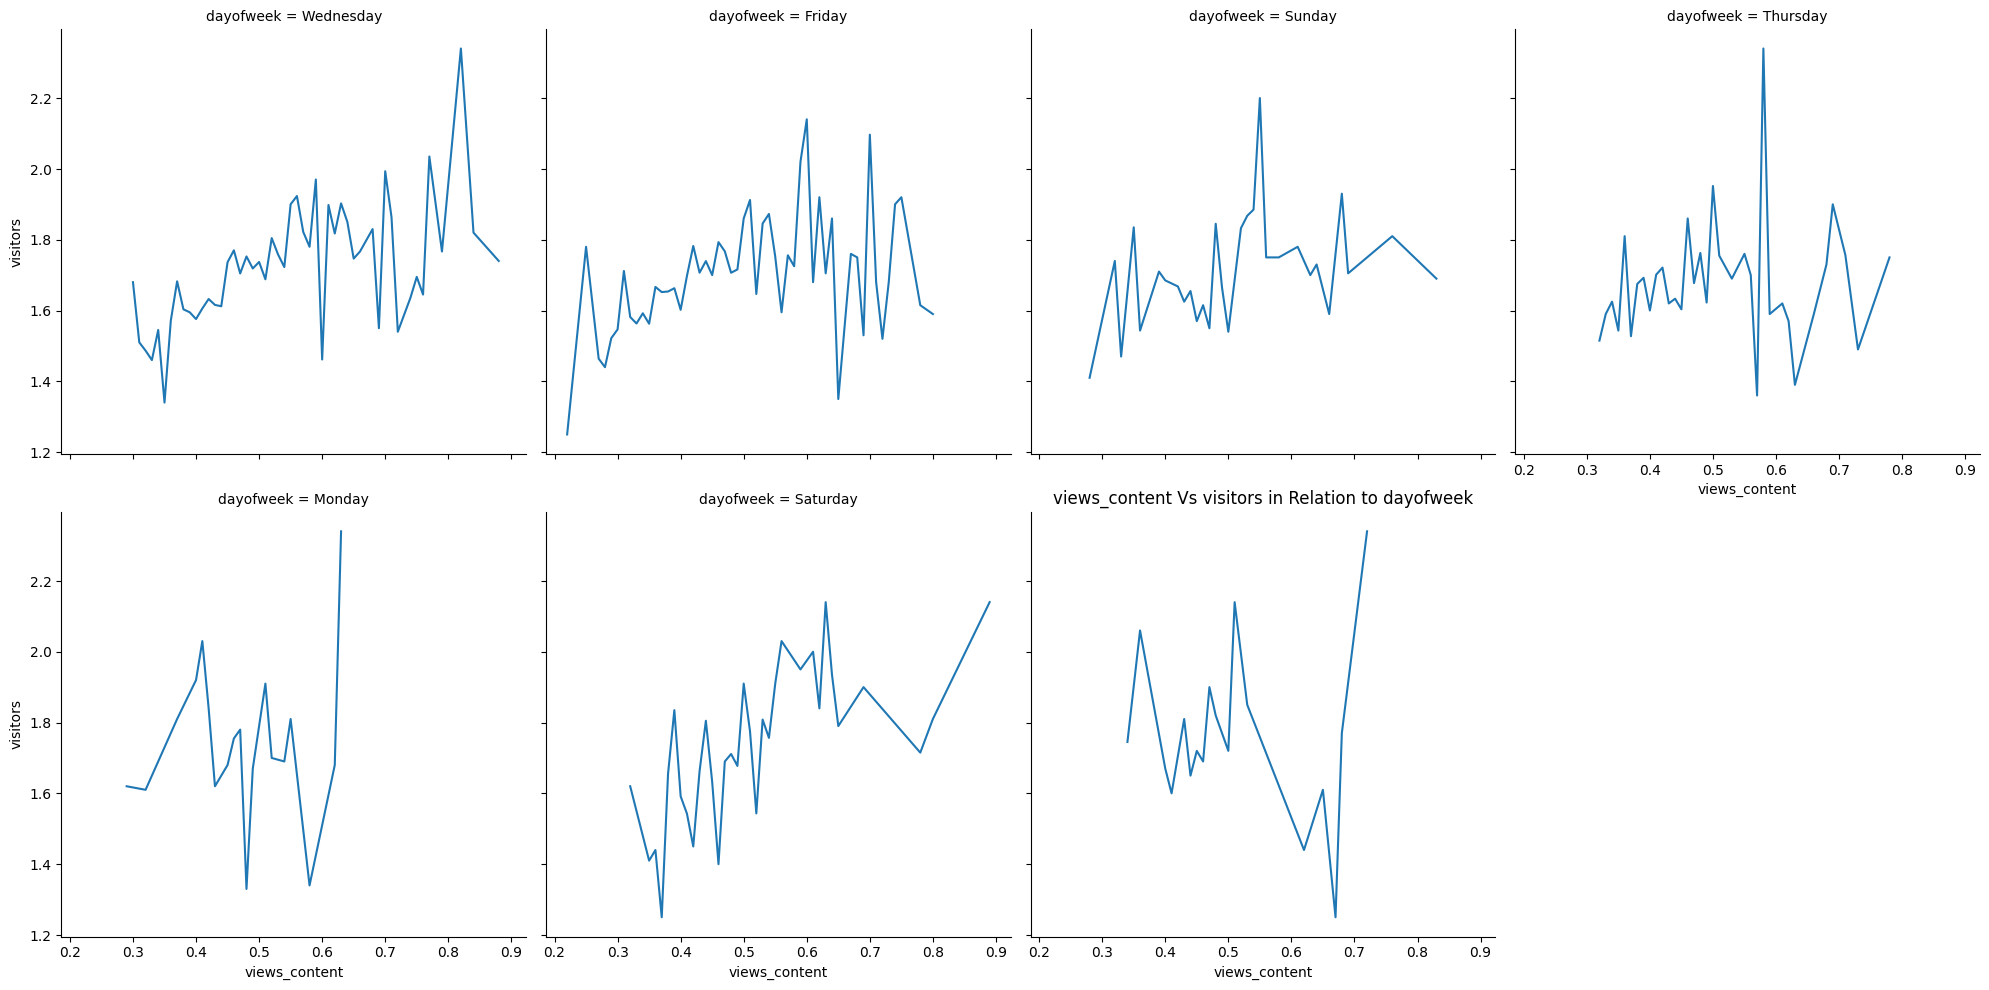

In [ ]:
sns.relplot(data=df,x='views_content',y='visitors',col='dayofweek',kind='line', ci=None, col_wrap=4);
plt.title('views_content Vs visitors in Relation to dayofweek')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visitors            1000 non-null   float64
 1   ad_impressions      1000 non-null   float64
 2   major_sports_event  1000 non-null   int64  
 3   genre               1000 non-null   object 
 4   dayofweek           1000 non-null   object 
 5   season              1000 non-null   object 
 6   views_trailer       1000 non-null   float64
 7   views_content       1000 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 62.6+ KB


**Question no 1**

**What does the distribution of content views look like?**

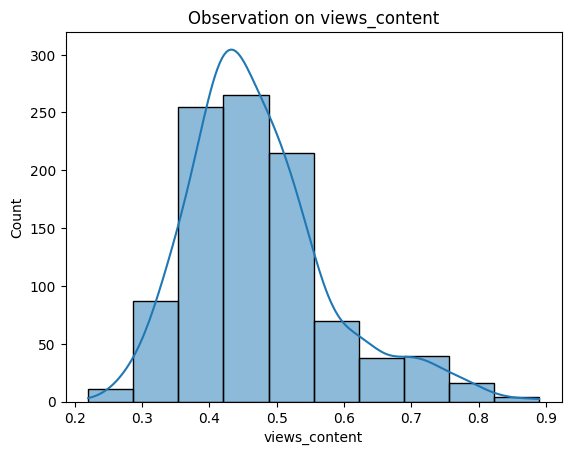

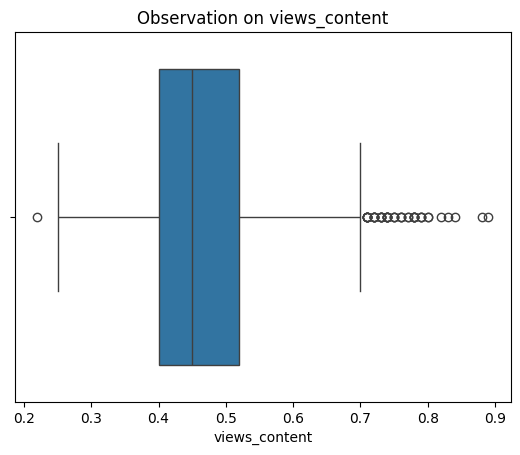

In [ ]:

plt.title('Observation on views_content')
sns.histplot(data=df,x='views_content',bins=10,kde=True);
plt.show()

plt.title('Observation on views_content')
sns.boxplot(data=df,x='views_content');
plt.show()

**Question No 2**

**What does the distribution of genres look like?**

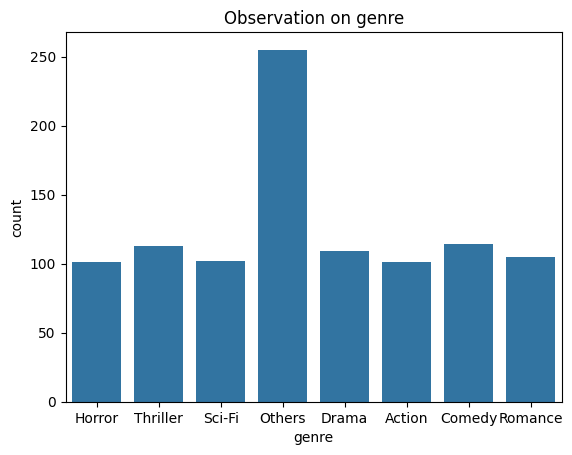

In [ ]:
plt.title('Observation on genre')
sns.countplot(data=df,x='genre');
plt.show()

**Question No: 3**

The day of the week on which content is released generally plays a key role in the viewership. How does the viewership vary with the day of release?

In [ ]:
df.groupby('dayofweek')['views_content'].describe()

,count,mean,std,min,25%,50%,75%,max
dayofweek,,,,,,,,
Friday,369.0,0.446694,0.101676,0.22,0.38,0.430,0.5000,0.80
Monday,24.0,0.467917,0.083353,0.29,0.42,0.465,0.5125,0.63
Saturday,88.0,0.497955,0.100678,0.32,0.43,0.480,0.5300,0.89
Sunday,67.0,0.484179,0.110373,0.28,0.42,0.470,0.5350,0.83
Thursday,97.0,0.470619,0.101034,0.32,0.41,0.450,0.5000,0.78
Tuesday,23.0,0.487826,0.109501,0.34,0.42,0.460,0.5200,0.72
Wednesday,332.0,0.494608,0.107614,0.30,0.42,0.480,0.5425,0.88


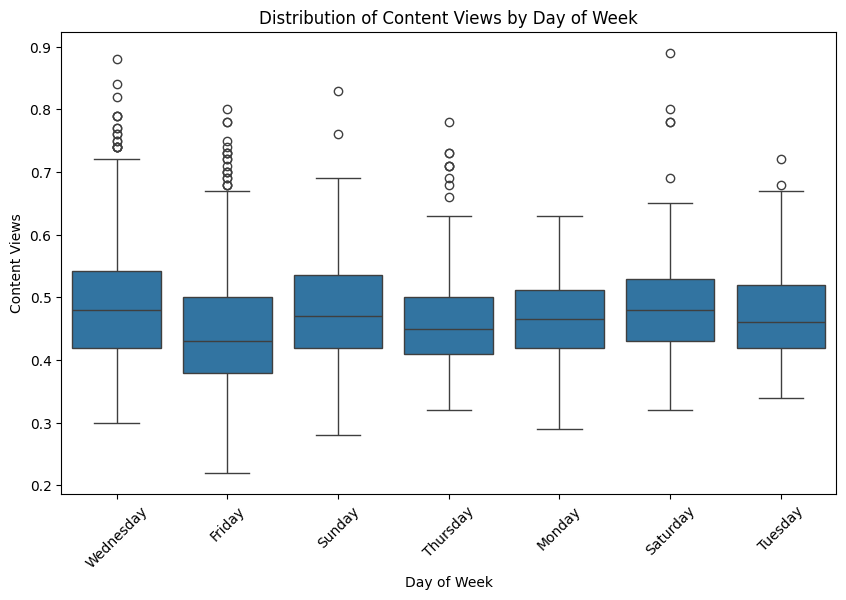

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="dayofweek", y="views_content")
plt.title("Distribution of Content Views by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Content Views")
plt.xticks(rotation=45)
plt.show()

**Question No: 4**

**How does the viewership vary with the season of release?**

In [ ]:
df.groupby('season')['views_content'].describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
Fall,252.0,0.445357,0.101539,0.25,0.38,0.43,0.5000,0.82
Spring,247.0,0.467166,0.097527,0.30,0.40,0.45,0.5100,0.79
Summer,244.0,0.496803,0.111697,0.22,0.42,0.48,0.5325,0.89
Winter,257.0,0.484669,0.105941,0.27,0.41,0.47,0.5400,0.84


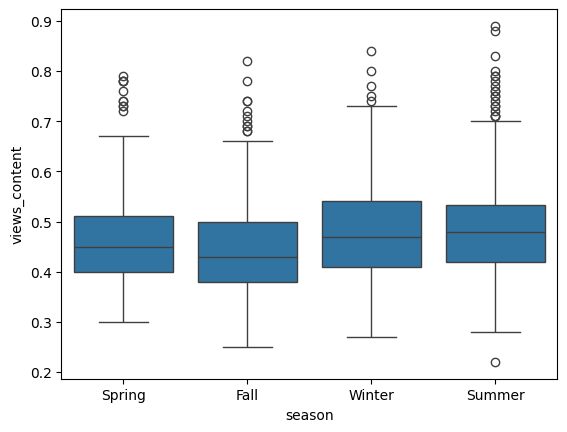

In [ ]:
sns.boxplot(x='season',y='views_content',data=df)
plt.show()

In [ ]:
df.groupby('season')['views_content'].describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
Fall,252.0,0.445357,0.101539,0.25,0.38,0.43,0.5000,0.82
Spring,247.0,0.467166,0.097527,0.30,0.40,0.45,0.5100,0.79
Summer,244.0,0.496803,0.111697,0.22,0.42,0.48,0.5325,0.89
Winter,257.0,0.484669,0.105941,0.27,0.41,0.47,0.5400,0.84


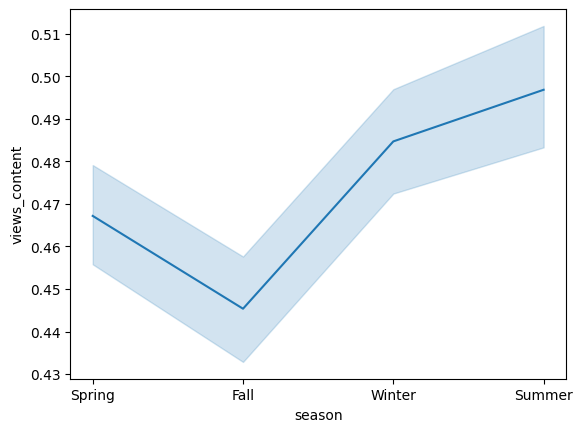

In [ ]:
sns.lineplot(x='season',y='views_content',data=df)
plt.show()

In [ ]:
# Group by season for summary stats
season_stats = df.groupby("season")["views_content"].agg(["mean", "median", "count"]).reset_index()
season_order = ["Spring", "Summer", "Fall", "Winter"]
season_stats["season"] = pd.Categorical(season_stats["season"], categories=season_order, ordered=True)
season_stats = season_stats.sort_values("season")

print("Viewership by Season:")
print(season_stats)

Viewership by Season:
   season      mean  median  count
1  Spring  0.467166    0.45    247
2  Summer  0.496803    0.48    244
0    Fall  0.445357    0.43    252
3  Winter  0.484669    0.47    257


**Question No 5**

**What is the correlation between trailer views and content views?**

In [ ]:
df['views_trailer'].corr(df['views_content'])

np.float64(0.753962214820536)

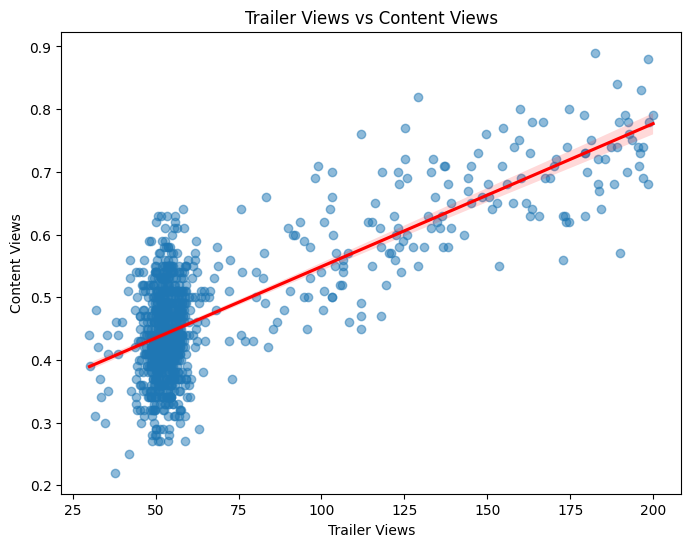

In [ ]:
# Scatter plot with regression line
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x="views_trailer", y="views_content", scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
plt.title("Trailer Views vs Content Views")
plt.xlabel("Trailer Views")
plt.ylabel("Content Views")
plt.show()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
visitors,0
ad_impressions,0
major_sports_event,0
genre,0
dayofweek,0
season,0
views_trailer,0
views_content,0


**Data Preparation for Modeling**

In [ ]:
# defining X and y variables
X = df.drop(["views_content"], axis=1)
y = df["views_content"]

print(X.head())
print(y.head())

   visitors  ad_impressions  major_sports_event     genre  dayofweek  season  \
0      1.67         1113.81                   0    Horror  Wednesday  Spring   
1      1.46         1498.41                   1  Thriller     Friday    Fall   
2      1.47         1079.19                   1  Thriller  Wednesday    Fall   
3      1.85         1342.77                   1    Sci-Fi     Friday    Fall   
4      1.46         1498.41                   0    Sci-Fi     Sunday  Winter   

   views_trailer  
0          56.70  
1          52.69  
2          48.74  
3          49.81  
4          55.83  
0    0.51
1    0.32
2    0.39
3    0.44
4    0.46
Name: views_content, dtype: float64


In [ ]:
# creating dummy variables
X = pd.get_dummies(
    X,
    columns=X.select_dtypes(include=["object", "category"]).columns.tolist(),
    drop_first=True
)
X.head()

,visitors,ad_impressions,major_sports_event,views_trailer,genre_Comedy,genre_Drama,genre_Horror,genre_Others,genre_Romance,genre_Sci-Fi,genre_Thriller,dayofweek_Monday,dayofweek_Saturday,dayofweek_Sunday,dayofweek_Thursday,dayofweek_Tuesday,dayofweek_Wednesday,season_Spring,season_Summer,season_Winter
0,1.67,1113.81,0,56.70,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False
1,1.46,1498.41,1,52.69,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
2,1.47,1079.19,1,48.74,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False
3,1.85,1342.77,1,49.81,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
4,1.46,1498.41,0,55.83,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True


In [ ]:
# converting the input attributes into float type for modeling
X = X.astype(float)
X.head()

,visitors,ad_impressions,major_sports_event,views_trailer,genre_Comedy,genre_Drama,genre_Horror,genre_Others,genre_Romance,genre_Sci-Fi,genre_Thriller,dayofweek_Monday,dayofweek_Saturday,dayofweek_Sunday,dayofweek_Thursday,dayofweek_Tuesday,dayofweek_Wednesday,season_Spring,season_Summer,season_Winter
0,1.67,1113.81,0.0,56.70,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,1.46,1498.41,1.0,52.69,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.47,1079.19,1.0,48.74,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.85,1342.77,1.0,49.81,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.46,1498.41,0.0,55.83,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
# splitting the data in 70:30 ratio for train to test data

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [ ]:
# let's add the intercept to data
x_train= sm.add_constant(x_train)

In [ ]:
# let's add the intercept to data
x_test= sm.add_constant(x_test)

In [ ]:
print("Number of rows in train data =", x_train.shape[0])
print("Number of rows in test data =", x_test.shape[0])

Number of rows in train data = 700
Number of rows in test data = 300


**Model Building - Linear Regression**

In [ ]:
olsmodel = sm.OLS(y_train, x_train).fit()
print(olsmodel.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     129.0
Date:                Sat, 16 Aug 2025   Prob (F-statistic):          1.32e-215
Time:                        15:52:43   Log-Likelihood:                 1124.6
No. Observations:                 700   AIC:                            -2207.
Df Residuals:                     679   BIC:                            -2112.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0602    

**Model Performance Check**

In [ ]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

In [ ]:
# checking model performance on train set (seen 70% data)
print("Train Performance\n")
olsmodel_train_perf_train = model_performance_regression(olsmodel, x_train, y_train)
olsmodel_train_perf_train

Train Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.04853,0.038197,0.791616,0.785162,8.55644


In [ ]:
# checking model performance on test set (seen 30% data)
print("Testing Performance\n")
olsmodel_train_perf_test = model_performance_regression(olsmodel, x_test, y_test)
olsmodel_train_perf_test

Testing Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.050603,0.040782,0.766447,0.748804,9.030464


**Checking Linear Regression Assumptions**

TEST FOR MULTICOLLINEARITY

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


def checking_vif(predictors):
    vif = pd.DataFrame()
    vif["feature"] = predictors.columns

    # calculating VIF for each feature
    vif["VIF"] = [
        variance_inflation_factor(predictors.values, i)
        for i in range(len(predictors.columns))
    ]
    return vif

In [ ]:
checking_vif(x_train)

,feature,VIF
0,const,99.679317
1,visitors,1.027837
2,ad_impressions,1.029390
3,major_sports_event,1.065689
4,views_trailer,1.023551
5,genre_Comedy,1.917635
6,genre_Drama,1.926699
7,genre_Horror,1.904460
8,genre_Others,2.573779
9,genre_Romance,1.753525


In [ ]:
# initial list of columns
predictors = x_train.copy()
cols = predictors.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    x_train_aux = predictors[cols]

    # fitting the model
    model = sm.OLS(y_train, x_train_aux).fit()

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(selected_features)

['const', 'visitors', 'major_sports_event', 'views_trailer', 'dayofweek_Monday', 'dayofweek_Saturday', 'dayofweek_Sunday', 'dayofweek_Thursday', 'dayofweek_Wednesday', 'season_Spring', 'season_Summer', 'season_Winter']


In [ ]:
x_train2 = x_train[selected_features]
x_test2 = x_test[selected_features]

In [ ]:
olsmod2 = sm.OLS(y_train, x_train2).fit()
print(olsmod2.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     233.8
Date:                Sat, 16 Aug 2025   Prob (F-statistic):          7.03e-224
Time:                        15:52:44   Log-Likelihood:                 1120.2
No. Observations:                 700   AIC:                            -2216.
Df Residuals:                     688   BIC:                            -2162.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0747    

**TEST FOR LINEARITY AND INDEPENDENCE**

In [ ]:
# let us create a dataframe with actual, fitted and residual values
df_pred = pd.DataFrame()

df_pred["Actual Values"] = y_train  # actual values
df_pred["Fitted Values"] = olsmod2.fittedvalues  # predicted values
df_pred["Residuals"] = olsmod2.resid  # residuals

df_pred.head()

,Actual Values,Fitted Values,Residuals
731,0.40,0.445434,-0.045434
716,0.70,0.677403,0.022597
640,0.42,0.433999,-0.013999
804,0.55,0.562030,-0.012030
737,0.59,0.547786,0.042214


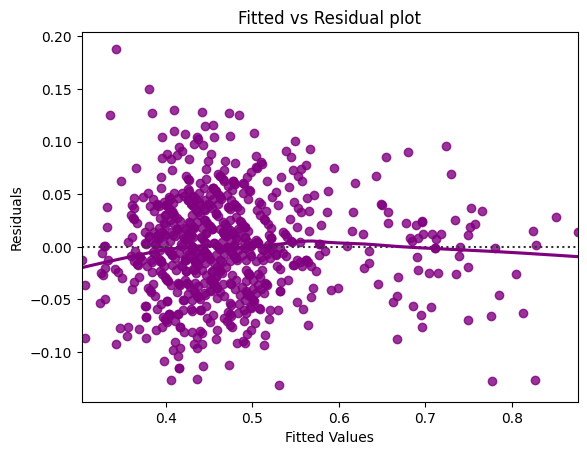

In [ ]:
# let's plot the fitted values vs residuals

sns.residplot(
    data=df_pred, x="Fitted Values", y="Residuals", color="purple", lowess=True
)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted vs Residual plot")
plt.show()


**TEST FOR NORMALITY**

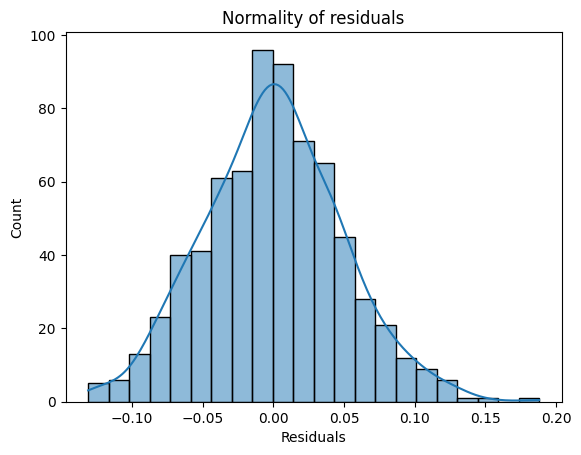

In [ ]:
sns.histplot(data=df_pred, x="Residuals", kde=True)
plt.title("Normality of residuals")
plt.show()

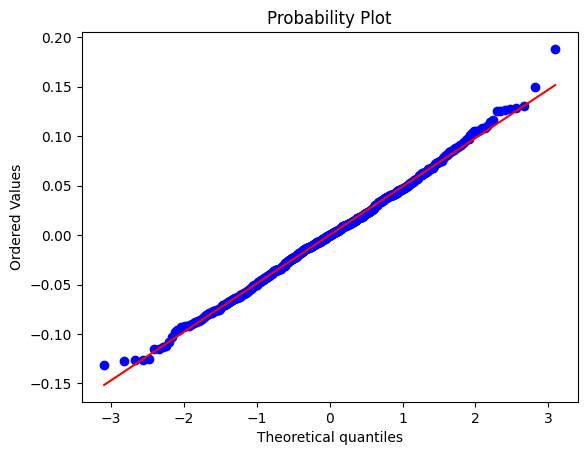

In [ ]:

import pylab
import scipy.stats as stats

stats.probplot(df_pred["Residuals"],dist="norm",plot=pylab)
plt.show()

In [ ]:
stats.shapiro(df_pred["Residuals"])

ShapiroResult(statistic=np.float64(0.9973155427169242), pvalue=np.float64(0.31085896470071894))

**TEST FOR HOMOSCEDASTICITY**

In [ ]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(df_pred["Residuals"], x_train2)
lzip(name, test)

[('F statistic', np.float64(1.1313612904200752)),
 ('p-value', np.float64(0.12853551819087372))]

In [ ]:
# predictions on the test set
pred = olsmod2.predict(x_test2)

df_pred_test = pd.DataFrame({"Actual": y_test, "Predicted": pred})
df_pred_test.sample(10, random_state=1)

,Actual,Predicted
983,0.43,0.434802
194,0.51,0.500314
314,0.48,0.430257
429,0.41,0.492544
267,0.41,0.487034
746,0.68,0.680000
186,0.62,0.595078
964,0.48,0.503909
676,0.42,0.490313
320,0.58,0.560155


**Final Model**

In [ ]:
x_train_final = x_train2.copy()
x_test_final = x_test2.copy()

In [ ]:
olsmodel_final = sm.OLS(y_train, x_train_final).fit()
print(olsmodel_final.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     233.8
Date:                Sat, 16 Aug 2025   Prob (F-statistic):          7.03e-224
Time:                        15:52:45   Log-Likelihood:                 1120.2
No. Observations:                 700   AIC:                            -2216.
Df Residuals:                     688   BIC:                            -2162.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0747    

In [ ]:
 #checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmodel_final_train_perf = model_performance_regression(
    olsmodel_final, x_train_final, y_train
)
olsmodel_final_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.048841,0.038385,0.788937,0.785251,8.595246


In [ ]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsmodel_final_test_perf = model_performance_regression(
    olsmodel_final, x_test_final, y_test
)
olsmodel_final_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.051109,0.041299,0.761753,0.751792,9.177097
